First 5 rows of dataset:
         Date     Open     High      Low    Close  Volume
0  2024-01-01  1513.87  1528.76  1478.55  1512.42   55486
1  2024-01-02  1513.10  1541.16  1470.12  1498.57  189407
2  2024-01-03  1509.71  1537.26  1485.85  1520.24  136900
3  2024-01-04  1539.23  1554.75  1513.94  1544.14  176020
4  2024-01-05  1496.35  1528.37  1475.86  1502.24  152795

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    90 non-null     object 
 1   Open    90 non-null     float64
 2   High    90 non-null     float64
 3   Low     90 non-null     float64
 4   Close   90 non-null     float64
 5   Volume  90 non-null     int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 4.3+ KB
None

Statistical Summary:
              Open         High          Low        Close         Volume
count    90.000000    90.000000    90.000000 

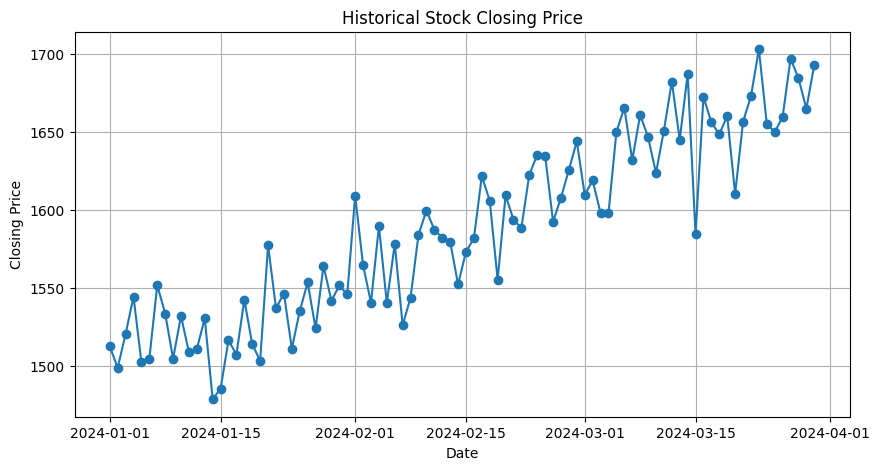


Actual and Predicted Closing Prices:
        Date    Close  Predicted_Close
0 2024-01-01  1512.42      1494.950977
1 2024-01-02  1498.57      1497.031409
2 2024-01-03  1520.24      1499.111842
3 2024-01-04  1544.14      1501.192274
4 2024-01-05  1502.24      1503.272707

Model Evaluation Results:
Mean Absolute Error: 18.50467409023214
Mean Squared Error: 537.9759803807752
Root Mean Squared Error: 23.194309224048368
R2 Score: 0.8444773985937312

Future Stock Price Forecast:
        Date  Predicted_Close
0 2024-03-31      1682.189900
1 2024-04-01      1684.270333
2 2024-04-02      1686.350765
3 2024-04-03      1688.431198
4 2024-04-04      1690.511630
5 2024-04-05      1692.592063
6 2024-04-06      1694.672495


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


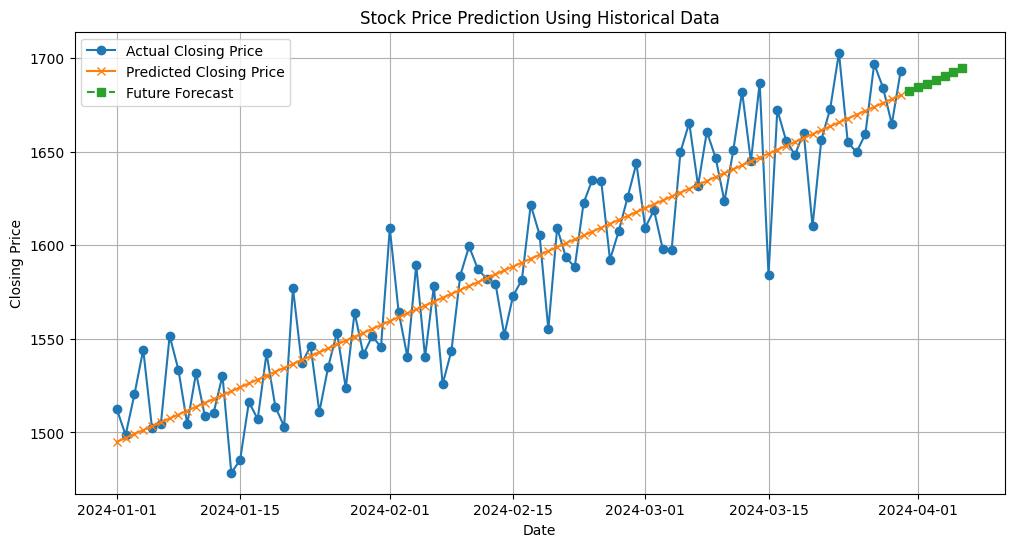


Output files saved successfully:
1. future_stock_price_forecast.csv
2. stock_price_with_predictions.csv
Complete output saved as complete_stock_prediction_output.csv


/tmp/ipykernel_4403/2365476233.py:144: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_output = pd.concat([actual_predicted, future_output], ignore_index=True)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("stock_price_dataset.csv")

print("First 5 rows of dataset:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

df['Date'] = pd.to_datetime(df['Date'])

print("\nDataset after converting Date column:")
print(df.head())

df['Day'] = np.arange(1, len(df) + 1)

print("\nDataset with Day column:")
print(df.head())

plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Close'], marker='o')
plt.title("Historical Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

X = df[['Day']]
y = df['Close']

model = LinearRegression()
model.fit(X, y)

df['Predicted_Close'] = model.predict(X)

print("\nActual and Predicted Closing Prices:")
print(df[['Date', 'Close', 'Predicted_Close']].head())

mae = mean_absolute_error(y, df['Predicted_Close'])
mse = mean_squared_error(y, df['Predicted_Close'])
rmse = np.sqrt(mse)
r2 = r2_score(y, df['Predicted_Close'])

print("\nModel Evaluation Results:")
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

future_days = np.arange(len(df) + 1, len(df) + 8).reshape(-1, 1)

future_predictions = model.predict(future_days)

future_dates = pd.date_range(
    start=df['Date'].iloc[-1] + pd.Timedelta(days=1),
    periods=7
)

future_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Close': future_predictions
})

print("\nFuture Stock Price Forecast:")
print(future_df)

plt.figure(figsize=(12, 6))

plt.plot(df['Date'], df['Close'], label='Actual Closing Price', marker='o')
plt.plot(df['Date'], df['Predicted_Close'], label='Predicted Closing Price', marker='x')
plt.plot(
    future_df['Date'],
    future_df['Predicted_Close'],
    label='Future Forecast',
    marker='s',
    linestyle='--'
)

plt.title("Stock Price Prediction Using Historical Data")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

future_df.to_csv("future_stock_price_forecast.csv", index=False)
df.to_csv("stock_price_with_predictions.csv", index=False)

print("\nOutput files saved successfully:")
print("1. future_stock_price_forecast.csv")
print("2. stock_price_with_predictions.csv")

import pandas as pd

# Select actual and predicted stock price data
actual_predicted = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Predicted_Close']].copy()

# Rename columns for clarity
actual_predicted.rename(columns={
    'Close': 'Actual_Close'
}, inplace=True)

# Add type column
actual_predicted['Data_Type'] = 'Historical Prediction'

# Prepare future forecast data
future_output = future_df.copy()

# Add missing columns to match historical data
future_output['Open'] = None
future_output['High'] = None
future_output['Low'] = None
future_output['Volume'] = None
future_output['Actual_Close'] = None
future_output['Data_Type'] = 'Future Forecast'

# Rename future prediction column
future_output.rename(columns={
    'Predicted_Close': 'Predicted_Close'
}, inplace=True)

# Arrange columns
future_output = future_output[
    ['Date', 'Open', 'High', 'Low', 'Actual_Close', 'Volume', 'Predicted_Close', 'Data_Type']
]

actual_predicted = actual_predicted[
    ['Date', 'Open', 'High', 'Low', 'Actual_Close', 'Volume', 'Predicted_Close', 'Data_Type']
]

# Combine both historical predictions and future forecast
final_output = pd.concat([actual_predicted, future_output], ignore_index=True)

# Save everything into one CSV file
final_output.to_csv("complete_stock_prediction_output.csv", index=False)

print("Complete output saved as complete_stock_prediction_output.csv")